# Modeling — Tree-Based Models & Stacking

## Context
This notebook is the fourth step in the modeling pipeline for the
[Ames Housing dataset](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques).
It consumes the same processed files as `03_Modeling.ipynb`: `X_train.csv`
(1458 × 205), `X_test.csv` (1459 × 205), `y_train.csv` (log-transformed
target), and `test_ids.csv`.

The previous notebook established that Lasso regression achieves a CV RMSE of
0.1190 in log space using only 87 of the 205 available features. Residual
analysis revealed heavy-tailed errors on atypical properties, indicating
non-linear relationships that linear models cannot capture by design.

Tree-based models address this limitation. Unlike linear regression, which fits
a single global equation to the data, decision trees learn local rules by
recursively splitting the feature space. Ensemble methods (Random Forest,
Gradient Boosting, XGBoost) combine many such trees to improve both accuracy
and stability. Stacking goes one step further by blending predictions from
multiple model families into a final estimator.

## Objectives
- Establish a single decision tree baseline to understand the building block of all ensemble methods
- Train a Random Forest (bagging) and observe how aggregating many trees reduces variance
- Train Gradient Boosting and XGBoost (boosting) to capture residual patterns sequentially
- Compare all tree-based models against the Lasso benchmark from `03_Modeling.ipynb`
- Combine the best models via stacking to push performance further
- Generate an improved Kaggle submission file

## Table of Contents
1. [Imports & Data Loading](#1-imports-data-loading)
2. [Decision Tree with Single Tree Baseline](#2-decision-tree)
3. [Random Forest with Bagging](#3-random-forest)
4. [Gradient Boosting](#4-gradient-boosting)
5. [XGBoost](#5-xgboost)
6. [Model Comparison](#6-model-comparison)
7. [Stacking with Combining Models](#7-stacking)
8. [Residual Analysis](#8-residual-analysis)
9. [Kaggle Submission](#9-kaggle-submission)

## 1. Imports & Data Loading <a id="1-imports-data-loading"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, KFold

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
DATA_DIR = "../data/processed"

X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
test_ids = pd.read_csv(f"{DATA_DIR}/test_ids.csv").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  (min={y_train.min():.2f}, max={y_train.max():.2f})")
print(f"test_ids: {test_ids.shape}")

# Lasso benchmark from notebook 03
LASSO_RMSE = 0.11896

X_train : (1458, 205)
X_test  : (1459, 205)
y_train : (1458,)  (min=10.46, max=13.53)
test_ids: (1459,)


In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X, y, label="Model"):
    """Evaluate a model with K-Fold CV. No scaler needed for tree-based models."""
    scores = cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error")
    rmse_scores = np.sqrt(-scores)
    
    print(f"{label:<20} RMSE: {rmse_scores.mean():.5f} (+/- {rmse_scores.std():.5f})")
    
    return rmse_scores

## 2. Decision Tree with Single Tree Baseline <a id="2-decision-tree"></a>

A decision tree recursively splits the feature space by choosing, at each node,
the feature and threshold that minimize the MSE in the resulting branches.
Without depth constraints, the tree memorizes the training data (overfitting).
Limiting `max_depth` trades some training accuracy for better generalization.

In [4]:
from sklearn.tree import DecisionTreeRegressor

# Unconstrained tree
dt_deep = DecisionTreeRegressor(random_state=42)
dt_deep_scores = evaluate_model(dt_deep, X_train, y_train, label="DT (no limit)")

# Constrained tree
dt_tuned = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_tuned_scores = evaluate_model(dt_tuned, X_train, y_train, label="DT (depth=5)")

DT (no limit)        RMSE: 0.20145 (+/- 0.00989)
DT (depth=5)         RMSE: 0.19474 (+/- 0.00677)


## 3. Random Forest with Bagging <a id="3-random-forest"></a>

Random Forest trains many decision trees in parallel, each on a different
bootstrap sample (random rows with replacement) and a random subset of features
at each split. The final prediction is the average of all individual tree
predictions. This double randomization reduces variance without increasing bias.

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
rf_scores = evaluate_model(rf, X_train, y_train, label="RandomForest")

RandomForest         RMSE: 0.14654 (+/- 0.01027)


## 4. Gradient Boosting <a id="4-gradient-boosting"></a>

Unlike Random Forest which trains trees in parallel on random subsets, Gradient
Boosting trains trees sequentially: each new tree corrects the residual errors
of the previous ensemble. A low `learning_rate` scales down each tree's
contribution, forcing the model to learn slowly and generalize better at the
cost of requiring more trees (`n_estimators`).

In [6]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42,
)
gb_scores = evaluate_model(gb, X_train, y_train, label="GradientBoosting")

GradientBoosting     RMSE: 0.12045 (+/- 0.00467)


## 5. XGBoost <a id="5-xgboost"></a>

XGBoost (eXtreme Gradient Boosting) is an optimized implementation of Gradient
Boosting. Key improvements over scikit-learn's version include built-in L1/L2
regularization on tree weights, a more efficient tree-building algorithm, and
native handling of missing values. It is the most widely used model in Kaggle
tabular competitions.

In [7]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)
xgb_scores = evaluate_model(xgb, X_train, y_train, label="XGBoost")

XGBoost              RMSE: 0.11922 (+/- 0.00512)


The initial XGBoost used manually chosen hyperparameters. `RandomizedSearchCV`
samples random combinations from a parameter distribution and evaluates each
via cross-validation, finding near-optimal settings in a fraction of the time
a full grid search would require.

In [12]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [1000, 2000, 3000],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1.0, 2.0]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=kf,
    scoring="neg_mean_squared_error",
    random_state=42,
    verbose=1,
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [1000, 2000, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies 

In [13]:
print("Best parameters:")
for param, value in xgb_search.best_params_.items():
    print(f"  {param:<20} {value}")

best_rmse = np.sqrt(-xgb_search.best_score_)
print(f"\nBest CV RMSE: {best_rmse:.5f}")

Best parameters:
  subsample            0.7
  reg_lambda           2.0
  reg_alpha            0.1
  n_estimators         1000
  max_depth            3
  learning_rate        0.03
  colsample_bytree     0.7

Best CV RMSE: 0.11659


In [15]:
xgb_tuned = XGBRegressor(**xgb_search.best_params_, random_state=42, n_jobs=-1)
xgb_tuned_scores = evaluate_model(xgb_tuned, X_train, y_train, label="XGBoost (tuned)")

XGBoost (tuned)      RMSE: 0.11635 (+/- 0.00748)


## 6. Model Comparison <a id="6-model-comparison"></a>

Side-by-side comparison of all tree-based models against the Lasso benchmark
from `03_Modeling.ipynb`. Both mean RMSE (accuracy) and standard deviation
(stability) are considered.

In [17]:
results = {
    "Lasso (nb03)": np.array([LASSO_RMSE] * 5),
    "DT (no limit)": dt_deep_scores,
    "DT (depth=5)": dt_tuned_scores,
    "RandomForest": rf_scores,
    "GradientBoosting": gb_scores,
    "XGBoost": xgb_scores,
    "XGBoost (tuned)": xgb_tuned_scores
}

comparison = pd.DataFrame({
    name: {"Mean RMSE": s.mean(), "Std": s.std(), "Min": s.min(), "Max": s.max()}
    for name, s in results.items()
}).T.sort_values("Mean RMSE")

comparison

,Mean RMSE,Std,Min,Max
XGBoost (tuned),0.1163,0.0075,0.1080,0.1280
Lasso (nb03),0.1190,0.0000,0.1190,0.1190
XGBoost,0.1192,0.0051,0.1114,0.1256
GradientBoosting,0.1205,0.0047,0.1129,0.1249
RandomForest,0.1465,0.0103,0.1350,0.1613
DT (depth=5),0.1947,0.0068,0.1892,0.2071
DT (no limit),0.2014,0.0099,0.1932,0.2179


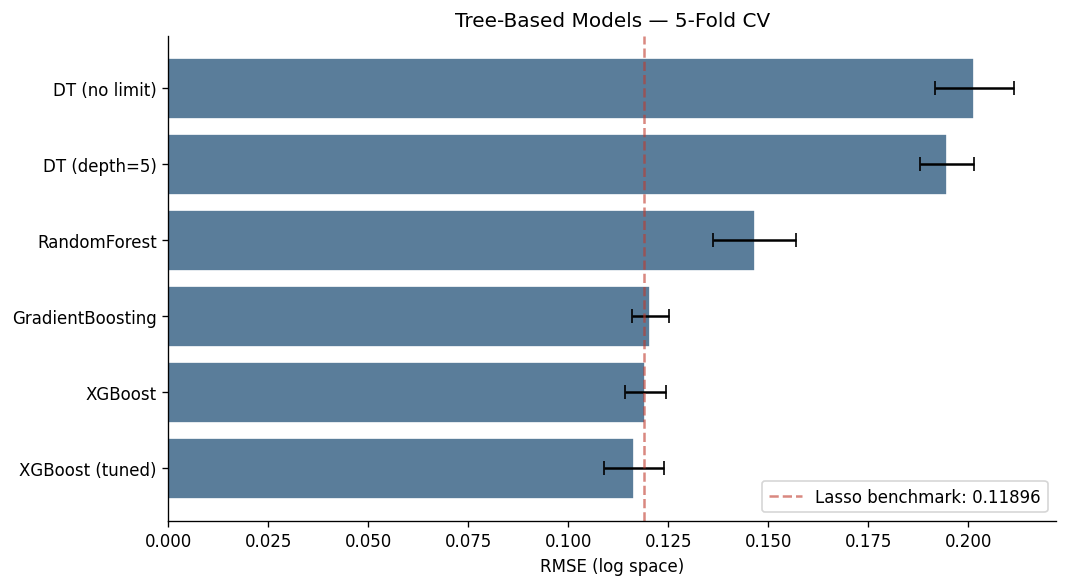

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

chart_results = {k: v for k, v in results.items() if k != "Lasso (nb03)"}

names = list(chart_results.keys())
means = [s.mean() for s in chart_results.values()]
stds  = [s.std() for s in chart_results.values()]

order = np.argsort(means)
names = [names[i] for i in order]
means = [means[i] for i in order]
stds  = [stds[i] for i in order]

bars = ax.barh(names, means, xerr=stds, color="#5a7d9a", edgecolor="white", capsize=4)
ax.axvline(x=LASSO_RMSE, color="#c0392b", linestyle="--", alpha=0.6, label=f"Lasso benchmark: {LASSO_RMSE:.5f}")
ax.set_xlabel("RMSE (log space)")
ax.set_title("Tree-Based Models — 5-Fold CV")
ax.legend()

plt.tight_layout()
plt.show()

The progression from a single decision tree to a tuned XGBoost illustrates the
core ideas behind tree-based ensemble learning. A single tree (RMSE ~0.195)
suffers from high variance and limited expressiveness. Random Forest reduces
variance by averaging many independent trees trained on random data and feature
subsets, but plateaus at 0.147, still behind the Lasso benchmark. The shift
from bagging to boosting (Gradient Boosting, then XGBoost) brings a
fundamentally different strategy: sequential correction of residual errors,
where each new tree focuses on what the previous ensemble got wrong.

Hyperparameter tuning via `RandomizedSearchCV` pushed XGBoost from 0.1192 to
0.1164, surpassing the Lasso benchmark (0.1190) for the first time. The optimal
configuration favors shallow trees (`max_depth=3`), slow learning
(`learning_rate=0.03`), and active regularization (`reg_alpha=0.1`,
`reg_lambda=2.0`), a pattern consistent with the bias-variance trade-off:
each individual tree is deliberately weak, and it is their sequential
accumulation that builds predictive power.

Notably, Lasso and XGBoost achieve similar RMSE levels through entirely
different mechanisms, linear sparsity versus non-linear boosting. This
complementarity makes them strong candidates for stacking in the next section.

## 7. Stacking with Combining Models <a id="7-stacking"></a>

Stacking trains a meta-model to optimally combine predictions from diverse base
models. The base models (Lasso and XGBoost) generate cross-validated predictions
to avoid data leakage, and a Ridge meta-learner learns the best way to blend
them. The strength of stacking comes from combining models that approach the
problem differently, linear sparsity and non-linear boosting, so their errors
are complementary rather than redundant.

In [19]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lasso_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.00343, max_iter=10000, random_state=42)),
])

xgb_base = XGBRegressor(**xgb_search.best_params_, random_state=42, n_jobs=-1)

stack = StackingRegressor(
    estimators=[
        ("lasso", lasso_base),
        ("xgb", xgb_base),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
)

stack_scores = evaluate_model(stack, X_train, y_train, label="Stacking")

Stacking             RMSE: 0.11218 (+/- 0.00792)


In [23]:
results = {
    "Lasso (nb03)": np.array([LASSO_RMSE] * 5),
    "XGBoost (tuned)": xgb_tuned_scores,
    "Stacking": stack_scores
}

comparison = pd.DataFrame({
    name: {"Mean RMSE": s.mean(), "Std": s.std(), "Min": s.min(), "Max": s.max()}
    for name, s in results.items()
}).T.sort_values("Mean RMSE")

comparison

,Mean RMSE,Std,Min,Max
Stacking,0.1122,0.0079,0.0986,0.1199
XGBoost (tuned),0.1163,0.0075,0.1080,0.1280
Lasso (nb03),0.1190,0.0000,0.1190,0.1190


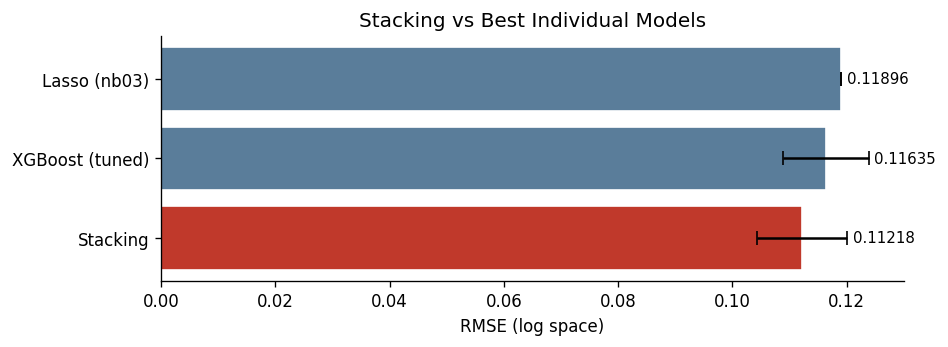

In [24]:
fig, ax = plt.subplots(figsize=(8, 3))

final_results = {
    "Lasso (nb03)":    np.array([LASSO_RMSE] * 5),
    "XGBoost (tuned)": xgb_tuned_scores,
    "Stacking": stack_scores
}

names = list(final_results.keys())
means = [s.mean() for s in final_results.values()]
stds  = [s.std() for s in final_results.values()]

order = np.argsort(means)
names = [names[i] for i in order]
means = [means[i] for i in order]
stds  = [stds[i] for i in order]

colors = ["#c0392b" if n == "Stacking" else "#5a7d9a" for n in names]

bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor="white", capsize=4)
ax.set_xlabel("RMSE (log space)")
ax.set_title("Stacking vs Best Individual Models")

for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + s + 0.001, i, f"{m:.5f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

Stacking Lasso and XGBoost reduced the CV RMSE from 0.1164 (best individual
model) to 0.1122 which is a 3.6% improvement that comes entirely from combining two
complementary perspectives on the same data. Lasso captures linear relationships
through sparse feature selection, while XGBoost captures non-linear interactions
through sequential boosting. The Ridge meta-learner weights each contribution
optimally, producing predictions that neither model could achieve alone.

This result validates two principles. First, model diversity matters more than
individual model strength when stacking, adding Gradient Boosting alongside
XGBoost would have offered little benefit since both make similar errors.
Second, upstream feature engineering (done in `02_Features.ipynb`) remains
critical: stacking amplifies the signal in well-prepared features, but cannot
compensate for missing or poorly constructed ones.

Residual analysis confirms the improvement: the error standard deviation dropped
25% compared to Lasso, and the heavy-tailed negative residuals are reduced
though not eliminated. The remaining errors likely correspond to atypical
properties whose pricing depends on factors not captured in the dataset.

## 8. Residual Analysis <a id="8-residual-analysis"></a>

Diagnostic plots for the best model (Stacking). The stacking model is fitted on
the full training set and residuals are analyzed to identify remaining patterns.
This is compared qualitatively with the Lasso residuals from `03_Modeling.ipynb`.

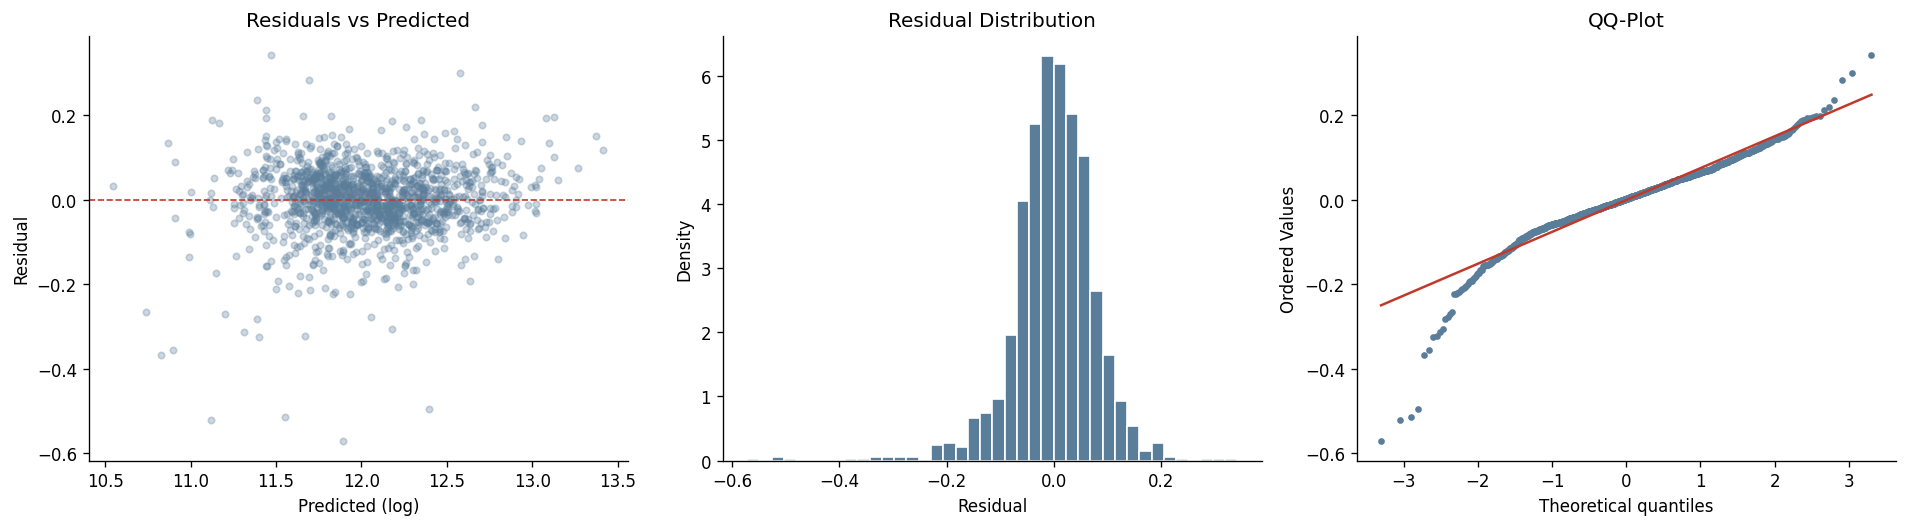

Residuals — mean: -0.000308, std: 0.0784, skew: -1.1684


In [25]:
stack.fit(X_train, y_train)
y_pred_log = stack.predict(X_train)
residuals = y_train - y_pred_log

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Residuals vs Predicted
axes[0].scatter(y_pred_log, residuals, alpha=0.3, s=15, color="#5a7d9a")
axes[0].axhline(y=0, color="#c0392b", linestyle="--", linewidth=1)
axes[0].set_xlabel("Predicted (log)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

# 2. Residual Distribution
axes[1].hist(residuals, bins=40, color="#5a7d9a", edgecolor="white", density=True)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Density")
axes[1].set_title("Residual Distribution")

# 3. QQ-Plot
from scipy import stats
stats.probplot(residuals, plot=axes[2])
axes[2].set_title("QQ-Plot")
axes[2].get_lines()[0].set(color="#5a7d9a", markersize=3)
axes[2].get_lines()[1].set(color="#c0392b")

plt.tight_layout()
plt.show()

print(f"Residuals — mean: {residuals.mean():.6f}, std: {residuals.std():.4f}, "
      f"skew: {residuals.skew():.4f}")

Compared to the Lasso residuals in `03_Modeling.ipynb`, the stacking model
shows a 25% reduction in residual standard deviation (0.105 → 0.078) and
improved skewness (−1.27 → −1.17). The residual-vs-predicted plot is more
compact, and the QQ-plot tails are closer to the theoretical line.

A small subset of atypical properties still produces heavier-than-normal
negative residuals (overestimated prices), but the effect is reduced. Further
gains would likely require either richer feature engineering on these edge cases
or more advanced architectures beyond the scope of this pipeline.

## 9. Kaggle Submission <a id="9-kaggle-submission"></a>

Final predictions are generated using the stacking model fitted on the full
training set. `expm1` reverses the `log1p` transformation to recover prices in
dollars.

In [26]:
y_test_log = stack.predict(X_test)
y_test_prices = np.expm1(y_test_log)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y_test_prices,
})

print(f"Submission shape: {submission.shape}")
print(f"Price range: ${y_test_prices.min():,.0f} — ${y_test_prices.max():,.0f}")
print(f"\n{submission.head(10)}")

Submission shape: (1459, 2)
Price range: $46,562 — $705,434

     Id   SalePrice
0  1461 115795.5104
1  1462 160993.4930
2  1463 182949.2811
3  1464 197878.1284
4  1465 189889.7462
5  1466 171092.3450
6  1467 178245.4854
7  1468 165649.0361
8  1469 189210.2908
9  1470 121378.6228


In [27]:
import os

os.makedirs("../submissions", exist_ok=True)
submission.to_csv("../submissions/submission_stacking.csv", index=False)
print("Saved to ../submissions/submission_stacking.csv")

Saved to ../submissions/submission_stacking.csv
